In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from os import listdir
from os.path import isfile, join
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from utils import analysis_utils
import re
from tqdm import tqdm
import json
import pandas as pd

In [46]:
# Extract all the datasets into a dictionary with the key as the name
data_path = "../../results/hidden_state_experiment"
regex = "eval_hidden_state_(.*).npy"
files = [f for f in listdir(data_path) if isfile(join(data_path, f))]
datasets = {}
for f in files:
    configName = re.search(regex, f).group(1)
    datasets[configName] = np.load(join(data_path, f))

In [47]:
# Compute the cosine similarities for the layer skipping approach
layer_wise_similarities = {}
layer_to_final_similarities = {}
full_model_hidden_states = datasets.pop("FM")
num_layers = full_model_hidden_states.shape[0]
num_tokens = full_model_hidden_states.shape[1]
for configName, skipping_model_hidden_states in tqdm(datasets):
    layer_wise_cosine_similarities = []
    layer_to_final_cosine_similarities = []
    for i in range(1, num_layers):
        layer_wise_cosine_similarities.append(analysis_utils.cosine_similarity(full_model_hidden_states[i], skipping_model_hidden_states[i]))
        layer_to_final_cosine_similarities.append(analysis_utils.cosine_similarity(full_model_hidden_states[-1], skipping_model_hidden_states[i]))
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities

0it [00:00, ?it/s]


In [50]:
# Compute the cosine similarities for the early exitting approach
for ee_layer in tqdm(range(1, num_layers-1)):
    configName = f"B{ee_layer}" # Stands for execute Bottom X layers
    early_exitting_hidden_states = np.append(full_model_hidden_states[:ee_layer], [full_model_hidden_states[ee_layer]] * (num_layers - ee_layer), axis=0) # Repeat the last hidden state before EE
    layer_wise_cosine_similarities = []
    layer_to_final_cosine_similarities = []
    for i in range(1, num_layers):
        layer_wise_cosine_similarities.append(analysis_utils.cosine_similarity(full_model_hidden_states[i], early_exitting_hidden_states[i]))
        layer_to_final_cosine_similarities.append(analysis_utils.cosine_similarity(full_model_hidden_states[-1], early_exitting_hidden_states[i]))
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities
    

100%|██████████| 12/12 [06:41<00:00, 33.49s/it]


In [75]:
# Save to json file
with open('layer_wise_similarities.json', 'w') as fout:
    json.dump(str(layer_wise_similarities), fout)
with open('layer_to_final_similarities.json', 'w') as fout:
    json.dump(str(layer_to_final_similarities), fout)

In [34]:
# # Load from json file
# with open('layer_wise_similarities.json', 'r') as fin:
#     layer_wise_similarities = eval(json.load(fin))
# with open('layer_to_final_similarities.json', 'r') as fin:
#     layer_to_final_similarities = eval(json.load(fin))

# Load from the multiple json files
methods = ["R","LS"]
layer_wise_similarities = {}
layer_to_final_similarities = {}
for method in methods:
    with open(f'layer_wise_similarities_{method}.json', 'r') as fin:
        layer_wise_similarities.update(eval(json.load(fin)))
    with open(f'layer_to_final_similarities_{method}.json', 'r') as fin:
        layer_to_final_similarities.update(eval(json.load(fin)))

In [35]:
# Extract the number of hidden states and number of tokens
num_layers = len(layer_wise_similarities["B1"]) + 1
print(f"Number of layers: {num_layers}")

Number of layers: 25


<Figure size 600x400 with 0 Axes>

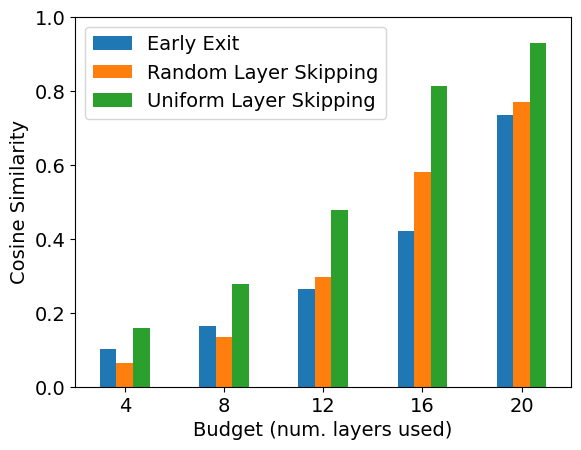

In [47]:
# Define the x-axis values
columns = ['Budget', 'B', 'R', 'LS']
labels = ['Budget', 'Early Exit', 'Random Layer Skipping', 'Uniform Layer Skipping']
#colors = ['lightblue', 'lightcoral', 'lightgreen']
budgets = [4, 8, 12, 16, 20]
groups = []

# Create a grouped bar chart using the dataframe example above as a reference
for budget in budgets:
    budget_list = [str(budget)]
    for strategy in columns[1:]:
        strat_layer_to_final_sims = layer_to_final_similarities[strategy + str(budget)]
        budget_list.append(strat_layer_to_final_sims[-1]) 
    groups.append(budget_list)

# Plot the grouped bar chart
df = pd.DataFrame(groups, columns=labels)
plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
ax = df.plot(x='Budget', kind='bar', stacked=False)
ax.set_xlabel("Budget (num. layers used)", fontsize=14)
ax.set_ylabel("Cosine Similarity", fontsize=14)
ax.tick_params(axis='x', labelrotation=0, labelsize=14)
ax.tick_params(axis='y', labelrotation=0, labelsize=14)
plt.yticks(np.arange(0, 1.1, step=0.2))
ax.legend(fontsize=14)

plt.savefig(f"cosine_similarity_vs_computational_budget.pdf",bbox_inches='tight')

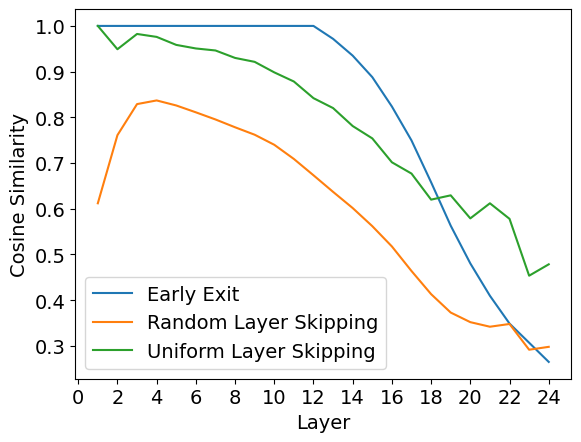

In [41]:
# Pick a budget
budget = 12

# Plot the layer-wise cosine similarities for that budget
plt.figure()
plot_res = {
    "Early Exit": None,
    "Random Layer Skipping": None,
    "Uniform Layer Skipping": None
}
for configName, similarities in layer_wise_similarities.items():
    regex = f".*([a-zA-Z]+){budget}"
    if re.match(regex, configName):
        if "LS" in configName:
            plot_res["Uniform Layer Skipping"] = similarities
        elif "R" in configName:
            plot_res["Random Layer Skipping"] = similarities
        elif "B" in configName:
            plot_res["Early Exit"] = similarities

for configName, similarities in plot_res.items():
    if similarities is not None:
        plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.xticks(range(0, num_layers,2))
plt.legend()
plt.savefig(f"layer_wise_cosine_similarity_budget_{budget}.pdf",bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Layer to final cosine similarities with full model')

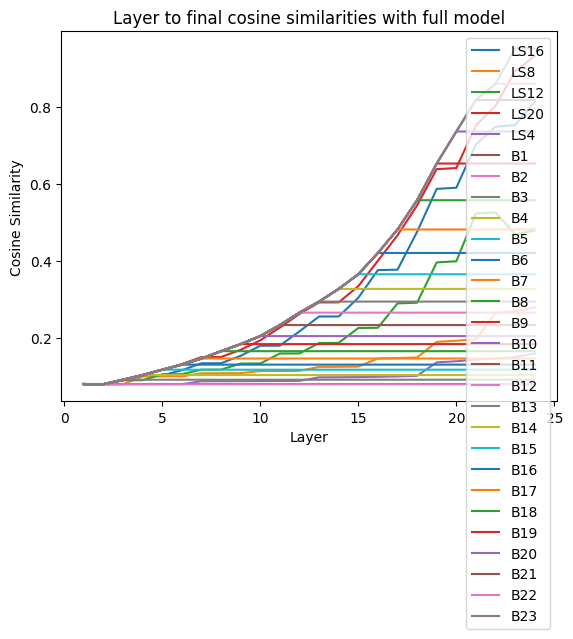

In [13]:
# Plot all the layer to final cosine similarities
plt.figure()
for configName, similarities in layer_to_final_similarities.items():
    plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.title("Layer to final cosine similarities with full model")